In [11]:
## E-Commerce Customer Segmentation and Behavioral Classification

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df=pd.read_csv("ecommerce_user_segmentation.csv")

In [37]:
df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold


In [39]:
df.shape

(10000, 14)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           10000 non-null  str    
 1   Recency               10000 non-null  int64  
 2   Frequency             10000 non-null  int64  
 3   Monetary              10000 non-null  int64  
 4   Avg_Order_Value       10000 non-null  int64  
 5   Session_Count         10000 non-null  int64  
 6   Avg_Session_Duration  10000 non-null  float64
 7   Pages_Viewed          10000 non-null  int64  
 8   Clicks                10000 non-null  int64  
 9   Campaign_Response     10000 non-null  int64  
 10  Wishlist_Adds         10000 non-null  int64  
 11  Cart_Abandon_Rate     10000 non-null  float64
 12  Returns               10000 non-null  int64  
 13  Segment_Label         10000 non-null  str    
dtypes: float64(2), int64(10), str(2)
memory usage: 1.1 MB


In [41]:
df.columns

Index(['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value',
       'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks',
       'Campaign_Response', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns',
       'Segment_Label'],
      dtype='str')

In [32]:
df.isnull().sum()

Customer_ID             0
Recency                 0
Frequency               0
Monetary                0
Avg_Order_Value         0
Session_Count           0
Avg_Session_Duration    0
Pages_Viewed            0
Clicks                  0
Campaign_Response       0
Wishlist_Adds           0
Cart_Abandon_Rate       0
Returns                 0
Segment_Label           0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,10000.0,48.665400,37.818734,1.000000,22.000000,40.000000,63.000000,179.000000
Frequency,10000.0,28.783000,23.133669,0.000000,10.000000,20.000000,40.000000,99.000000
Monetary,10000.0,1938.394600,2327.840348,0.000000,269.000000,1022.000000,2825.250000,9995.000000
Avg_Order_Value,10000.0,146.599900,87.564246,10.000000,79.000000,135.000000,196.000000,399.000000
Session_Count,10000.0,55.915800,43.551484,0.000000,22.000000,44.000000,75.000000,199.000000
Avg_Session_Duration,10000.0,15.444645,8.133285,1.000433,9.515457,14.305176,19.725305,39.995729
Pages_Viewed,10000.0,33.998400,21.142060,1.000000,18.000000,30.000000,46.000000,99.000000
Clicks,10000.0,1211.465100,1058.875362,50.000000,451.750000,871.000000,1518.000000,4998.000000
Campaign_Response,10000.0,0.416700,0.493037,0.000000,0.000000,0.000000,1.000000,1.000000
Wishlist_Adds,10000.0,28.618300,23.544257,0.000000,11.000000,21.000000,41.000000,99.000000


In [35]:
df["Segment_Label"].value_counts()

Segment_Label
Silver      3055
Copper      2444
Gold        2022
Iron        1448
Platinum    1031
Name: count, dtype: int64

In [36]:
df.groupby("Segment_Label")[[
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Session_Count",
    "Avg_Session_Duration",
    "Pages_Viewed",
    "Clicks",
    "Wishlist_Adds",
    "Cart_Abandon_Rate",
    "Returns"
]].mean().round(2)

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Wishlist_Adds,Cart_Abandon_Rate,Returns
Segment_Label,,,,,,,,,,,
Copper,59.30,12.04,298.93,84.35,24.42,9.96,19.66,497.18,12.18,22.41,9.45
Gold,19.50,49.55,3508.50,223.58,89.23,22.43,49.32,1981.43,49.81,9.88,4.47
Iron,120.05,4.55,48.46,28.87,9.59,5.41,7.45,174.78,2.02,35.01,11.85
Platinum,7.51,74.10,7478.51,299.37,149.06,29.90,74.05,3476.15,74.23,5.01,2.04
Silver,39.52,24.62,1236.88,149.69,49.59,15.09,34.40,1000.36,24.96,15.03,6.97


In [42]:
df["Segment_Label"].value_counts(normalize=True) * 100

Segment_Label
Silver      30.55
Copper      24.44
Gold        20.22
Iron        14.48
Platinum    10.31
Name: proportion, dtype: float64

In [44]:
segment_counts = df["Segment_Label"].value_counts()

segment_counts

Segment_Label
Silver      3055
Copper      2444
Gold        2022
Iron        1448
Platinum    1031
Name: count, dtype: int64

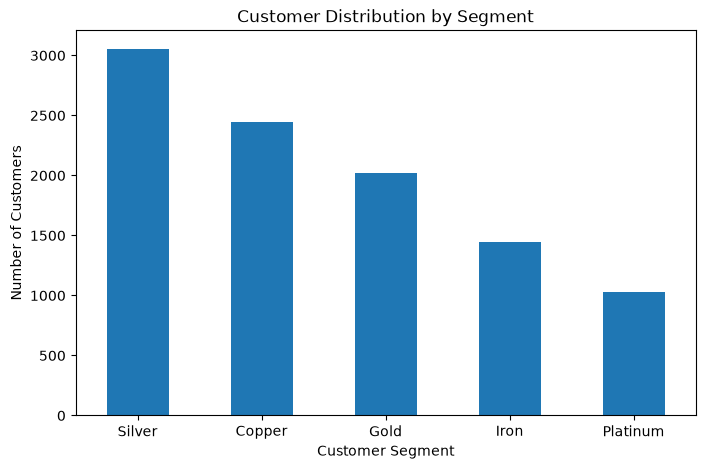

In [45]:
plt.figure(figsize=(8, 5))

segment_counts.plot(kind="bar")

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [46]:
rfm_mean = df.groupby("Segment_Label")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

rfm_mean

,Recency,Frequency,Monetary
Segment_Label,,,
Copper,59.30,12.04,298.93
Gold,19.50,49.55,3508.50
Iron,120.05,4.55,48.46
Platinum,7.51,74.10,7478.51
Silver,39.52,24.62,1236.88


In [47]:
rfm_median = df.groupby("Segment_Label")[[
    "Recency",
    "Frequency",
    "Monetary"
]].median().round(2)

rfm_median

,Recency,Frequency,Monetary
Segment_Label,,,
Copper,59.0,12.0,298.0
Gold,20.0,50.0,3476.5
Iron,121.0,5.0,48.0
Platinum,7.0,73.0,7525.0
Silver,40.0,25.0,1231.0


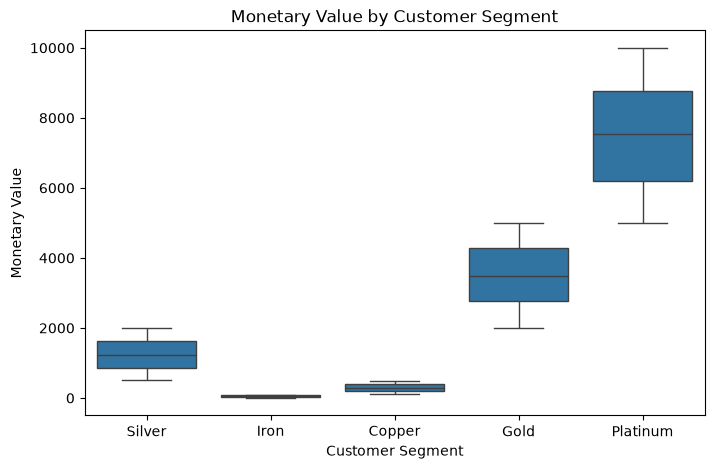

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Segment_Label", y="Monetary")

plt.title("Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Monetary Value")

plt.show()

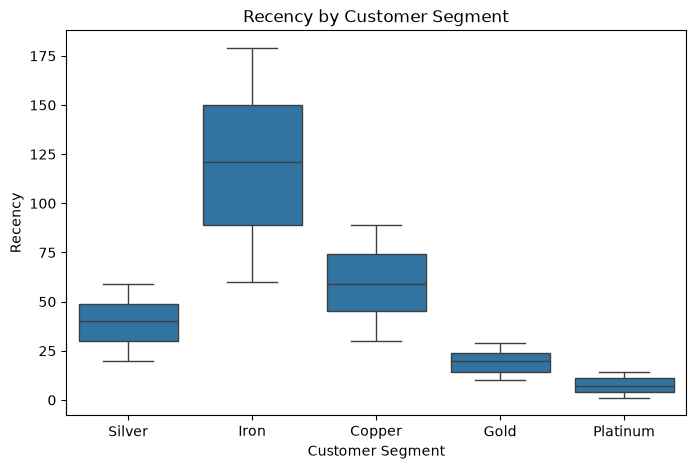

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Segment_Label", y="Recency")

plt.title("Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Recency")

plt.show()

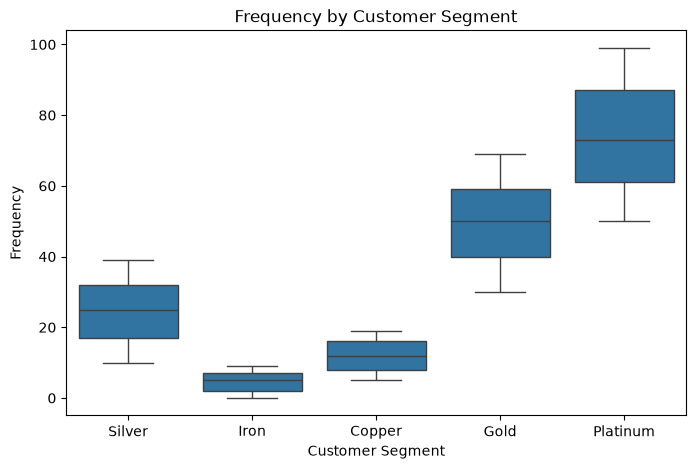

In [50]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Segment_Label", y="Frequency")

plt.title("Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Frequency")

plt.show()

In [51]:
engagement_mean = df.groupby("Segment_Label")[[
    "Session_Count",
    "Avg_Session_Duration",
    "Pages_Viewed",
    "Clicks",
    "Wishlist_Adds"
]].mean().round(2)

engagement_mean

,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Wishlist_Adds
Segment_Label,,,,,
Copper,24.42,9.96,19.66,497.18,12.18
Gold,89.23,22.43,49.32,1981.43,49.81
Iron,9.59,5.41,7.45,174.78,2.02
Platinum,149.06,29.90,74.05,3476.15,74.23
Silver,49.59,15.09,34.40,1000.36,24.96


In [52]:
conversion_mean = df.groupby("Segment_Label")[[
    "Cart_Abandon_Rate",
    "Returns",
    "Campaign_Response"
]].mean().round(2)

conversion_mean

,Cart_Abandon_Rate,Returns,Campaign_Response
Segment_Label,,,
Copper,22.41,9.45,0.30
Gold,9.88,4.47,0.61
Iron,35.01,11.85,0.10
Platinum,5.01,2.04,0.80
Silver,15.03,6.97,0.41


In [53]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

correlation.round(2)

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns
Recency,1.00,-0.68,-0.62,-0.75,-0.69,-0.71,-0.72,-0.65,-0.34,-0.70,0.79,0.43
Frequency,-0.68,1.00,0.87,0.84,0.87,0.83,0.83,0.84,0.37,0.86,-0.73,-0.47
Monetary,-0.62,0.87,1.00,0.83,0.89,0.82,0.83,0.87,0.36,0.87,-0.68,-0.45
Avg_Order_Value,-0.75,0.84,0.83,1.00,0.85,0.83,0.83,0.82,0.38,0.85,-0.79,-0.48
Session_Count,-0.69,0.87,0.89,0.85,1.00,0.84,0.84,0.86,0.37,0.87,-0.74,-0.47
Avg_Session_Duration,-0.71,0.83,0.82,0.83,0.84,1.00,0.81,0.81,0.37,0.83,-0.75,-0.46
Pages_Viewed,-0.72,0.83,0.83,0.83,0.84,0.81,1.00,0.81,0.37,0.83,-0.75,-0.46
Clicks,-0.65,0.84,0.87,0.82,0.86,0.81,0.81,1.00,0.36,0.84,-0.70,-0.45
Campaign_Response,-0.34,0.37,0.36,0.38,0.37,0.37,0.37,0.36,1.00,0.37,-0.35,-0.22
Wishlist_Adds,-0.70,0.86,0.87,0.85,0.87,0.83,0.83,0.84,0.37,1.00,-0.75,-0.47


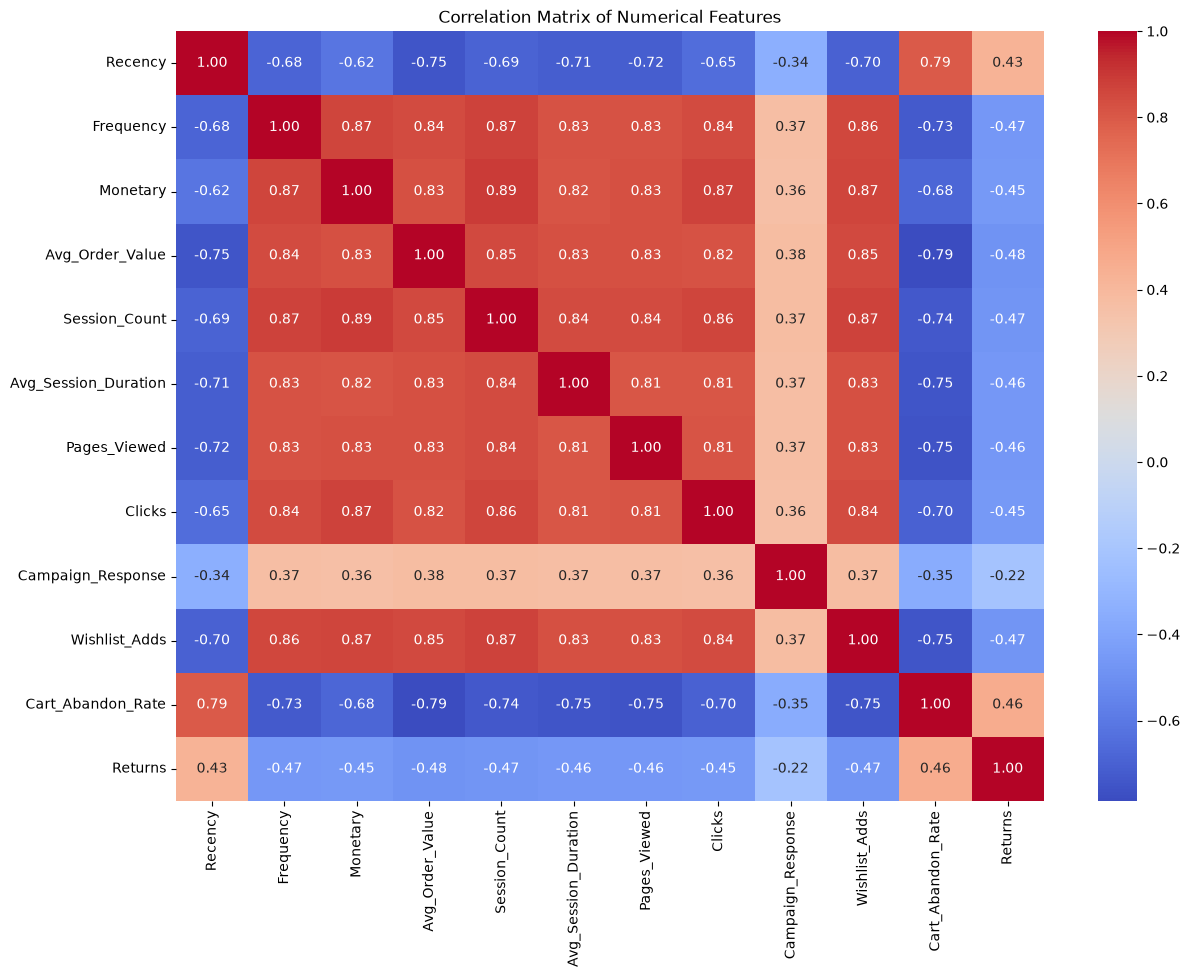

In [54]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [55]:
for col in ["Campaign_Response"]:
    print(col, df[col].unique())

Campaign_Response [1 0]


In [56]:
print("Recency:", df["Recency"].min(), "to", df["Recency"].max())
print("Frequency:", df["Frequency"].min(), "to", df["Frequency"].max())
print("Monetary:", df["Monetary"].min(), "to", df["Monetary"].max())
print("Avg Order Value:", df["Avg_Order_Value"].min(), "to", df["Avg_Order_Value"].max())
print("Cart Abandon Rate:", df["Cart_Abandon_Rate"].min(), "to", df["Cart_Abandon_Rate"].max())
print("Returns:", df["Returns"].min(), "to", df["Returns"].max())

Recency: 1 to 179
Frequency: 0 to 99
Monetary: 0 to 9995
Avg Order Value: 10 to 399
Cart Abandon Rate: 0.0070501183615223 to 49.99425443521295
Returns: 0 to 24


In [57]:
df[(df["Frequency"] == 0) & (df["Monetary"] > 0)].shape

(143, 14)

In [58]:
df[(df["Frequency"] == 0) & (df["Monetary"] > 0)].head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label
192,CUST00193,136,0,54,11,1,5.667535,5,245,0,1,45.939773,2,Iron
198,CUST00199,77,0,68,25,14,9.680586,2,97,0,1,25.858200,19,Iron
252,CUST00253,155,0,47,31,13,9.610549,7,221,1,0,32.331277,9,Iron
256,CUST00257,158,0,73,41,9,2.888439,8,267,0,2,37.975269,18,Iron
261,CUST00262,151,0,62,48,1,8.139067,13,170,0,2,48.360991,17,Iron


In [59]:
df[(df["Frequency"] == 0) & (df["Avg_Order_Value"] > 0)].shape

(145, 14)

In [60]:
df[df["Returns"] > df["Frequency"]].shape

(2010, 14)

In [61]:
check1 = df[(df["Frequency"] == 0) & (df["Monetary"] > 0)]

print("Inconsistent records:", len(check1))

Inconsistent records: 143


In [62]:
df[(df["Frequency"] == 0) & (df["Avg_Order_Value"] > 0)][[
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Session_Count",
    "Returns",
    "Segment_Label"
]].describe()

,Frequency,Monetary,Avg_Order_Value,Session_Count,Returns
count,145.0,145.000000,145.000000,145.000000,145.000000
mean,0.0,47.013793,30.241379,9.406897,12.082759
std,0.0,27.982630,12.116492,5.408964,7.211587
min,0.0,0.000000,11.000000,1.000000,0.000000
25%,0.0,28.000000,20.000000,5.000000,6.000000
50%,0.0,45.000000,30.000000,9.000000,12.000000
75%,0.0,73.000000,41.000000,14.000000,18.000000
max,0.0,99.000000,49.000000,19.000000,24.000000


In [63]:
zero_frequency = df[df["Frequency"] == 0]

zero_frequency[[
    "Customer_ID",
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Session_Count",
    "Pages_Viewed",
    "Clicks",
    "Cart_Abandon_Rate",
    "Returns",
    "Segment_Label"
]].head(20)

,Customer_ID,Frequency,Monetary,Avg_Order_Value,Session_Count,Pages_Viewed,Clicks,Cart_Abandon_Rate,Returns,Segment_Label
183,CUST00184,0,0,41,7,8,240,23.005080,6,Iron
192,CUST00193,0,54,11,1,5,245,45.939773,2,Iron
198,CUST00199,0,68,25,14,2,97,25.858200,19,Iron
252,CUST00253,0,47,31,13,7,221,32.331277,9,Iron
256,CUST00257,0,73,41,9,8,267,37.975269,18,Iron
261,CUST00262,0,62,48,1,13,170,48.360991,17,Iron
272,CUST00273,0,30,25,8,1,160,33.831469,3,Iron
351,CUST00352,0,87,24,2,5,66,23.065170,9,Iron
396,CUST00397,0,81,16,19,12,107,28.567630,15,Iron
427,CUST00428,0,31,16,18,5,107,24.391278,6,Iron


In [64]:
zero_frequency["Segment_Label"].value_counts()

Segment_Label
Iron    145
Name: count, dtype: int64

In [65]:
returns_issue = df[df["Returns"] > df["Frequency"]]

returns_issue[[
    "Frequency",
    "Returns",
    "Monetary",
    "Avg_Order_Value",
    "Segment_Label"
]].head(20)

,Frequency,Returns,Monetary,Avg_Order_Value,Segment_Label
1,5,9,3,26,Iron
2,15,16,235,57,Copper
7,1,3,98,28,Iron
11,6,12,56,29,Iron
33,5,8,6,24,Iron
34,2,20,43,40,Iron
35,12,13,462,73,Copper
43,5,22,42,30,Iron
50,5,11,97,17,Iron
51,7,12,208,88,Copper


In [66]:
returns_issue["Segment_Label"].value_counts()

Segment_Label
Iron      1117
Copper     828
Silver      65
Name: count, dtype: int64

In [67]:
segment_value = df.groupby("Segment_Label").agg(
    Total_Monetary=("Monetary", "sum"),
    Average_Monetary=("Monetary", "mean"),
    Average_Order_Value=("Avg_Order_Value", "mean")
).round(2)

segment_value

,Total_Monetary,Average_Monetary,Average_Order_Value
Segment_Label,,,
Copper,730591,298.93,84.35
Gold,7094182,3508.50,223.58
Iron,70173,48.46,28.87
Platinum,7710339,7478.51,299.37
Silver,3778661,1236.88,149.69


In [68]:
engagement = df.groupby("Segment_Label").agg(
    Avg_Session_Count=("Session_Count", "mean"),
    Avg_Session_Duration=("Avg_Session_Duration", "mean"),
    Avg_Pages_Viewed=("Pages_Viewed", "mean"),
    Avg_Clicks=("Clicks", "mean"),
    Avg_Wishlist_Adds=("Wishlist_Adds", "mean")
).round(2)

engagement

,Avg_Session_Count,Avg_Session_Duration,Avg_Pages_Viewed,Avg_Clicks,Avg_Wishlist_Adds
Segment_Label,,,,,
Copper,24.42,9.96,19.66,497.18,12.18
Gold,89.23,22.43,49.32,1981.43,49.81
Iron,9.59,5.41,7.45,174.78,2.02
Platinum,149.06,29.90,74.05,3476.15,74.23
Silver,49.59,15.09,34.40,1000.36,24.96


In [69]:
purchase_behavior = df.groupby("Segment_Label").agg(
    Avg_Cart_Abandonment=("Cart_Abandon_Rate", "mean"),
    Avg_Returns=("Returns", "mean"),
    Campaign_Response_Rate=("Campaign_Response", "mean")
).round(2)

purchase_behavior

,Avg_Cart_Abandonment,Avg_Returns,Campaign_Response_Rate
Segment_Label,,,
Copper,22.41,9.45,0.30
Gold,9.88,4.47,0.61
Iron,35.01,11.85,0.10
Platinum,5.01,2.04,0.80
Silver,15.03,6.97,0.41


In [70]:
campaign_analysis = pd.crosstab(
    df["Segment_Label"],
    df["Campaign_Response"],
    normalize="index"
).round(3) * 100

campaign_analysis

Campaign_Response,0,1
Segment_Label,,
Copper,70.4,29.6
Gold,39.1,60.9
Iron,90.0,10.0
Platinum,20.4,79.6
Silver,59.2,40.8


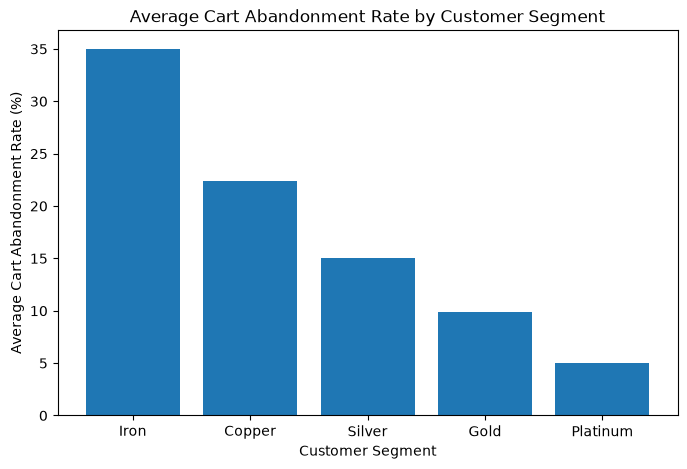

In [71]:
import matplotlib.pyplot as plt

cart_abandonment = df.groupby("Segment_Label")["Cart_Abandon_Rate"].mean()

cart_abandonment = cart_abandonment.reindex(
    ["Iron", "Copper", "Silver", "Gold", "Platinum"]
)

plt.figure(figsize=(8,5))
plt.bar(cart_abandonment.index, cart_abandonment.values)

plt.title("Average Cart Abandonment Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Cart Abandonment Rate (%)")

plt.show()

In [72]:
iron_rate = cart_abandonment["Iron"]
platinum_rate = cart_abandonment["Platinum"]

print("Iron:", iron_rate)
print("Platinum:", platinum_rate)
print("Difference:", iron_rate - platinum_rate)

Iron: 35.01064712380626
Platinum: 5.010452251903316
Difference: 30.00019487190294


In [73]:
correlations = df[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Avg_Order_Value",
        "Session_Count",
        "Avg_Session_Duration",
        "Pages_Viewed",
        "Clicks",
        "Campaign_Response",
        "Wishlist_Adds",
        "Cart_Abandon_Rate",
        "Returns"
    ]
].corr()["Monetary"].sort_values(ascending=False)

correlations

Monetary                1.000000
Session_Count           0.890734
Clicks                  0.869714
Wishlist_Adds           0.867322
Frequency               0.865951
Pages_Viewed            0.829674
Avg_Order_Value         0.825762
Avg_Session_Duration    0.817371
Campaign_Response       0.364264
Returns                -0.453745
Recency                -0.619307
Cart_Abandon_Rate      -0.675807
Name: Monetary, dtype: float64

<Figure size 900x500 with 0 Axes>

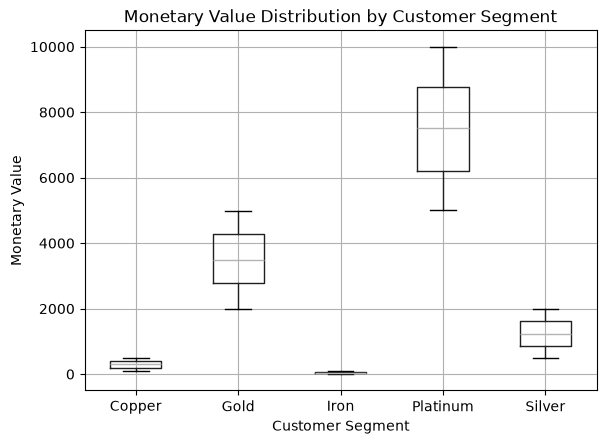

In [74]:
plt.figure(figsize=(9,5))

df.boxplot(
    column="Monetary",
    by="Segment_Label"
)

plt.title("Monetary Value Distribution by Customer Segment")
plt.suptitle("")
plt.xlabel("Customer Segment")
plt.ylabel("Monetary Value")

plt.show()

In [75]:
segment_engagement = df.groupby("Segment_Label")[
    ["Session_Count", "Pages_Viewed", "Clicks", "Wishlist_Adds"]
].mean().round(2)

segment_engagement

,Session_Count,Pages_Viewed,Clicks,Wishlist_Adds
Segment_Label,,,,
Copper,24.42,19.66,497.18,12.18
Gold,89.23,49.32,1981.43,49.81
Iron,9.59,7.45,174.78,2.02
Platinum,149.06,74.05,3476.15,74.23
Silver,49.59,34.40,1000.36,24.96


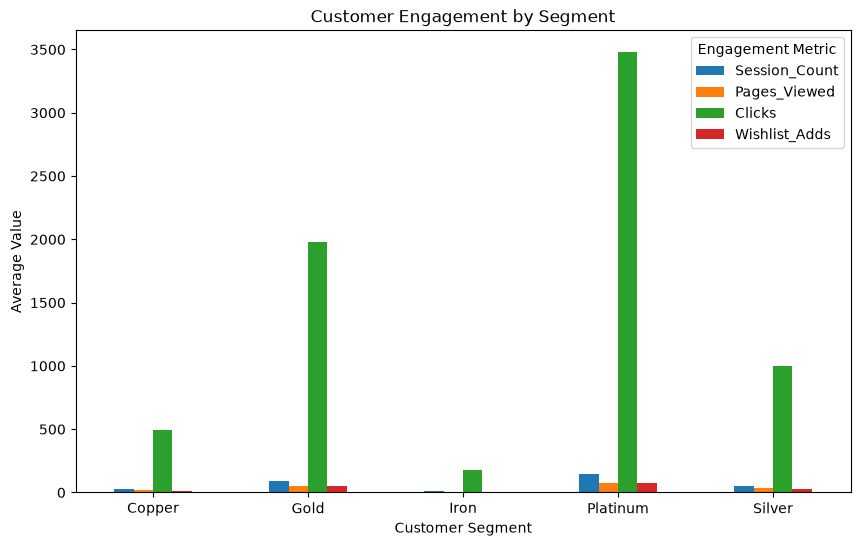

In [76]:
segment_engagement.plot(kind="bar", figsize=(10, 6))

plt.title("Customer Engagement by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Engagement Metric")

plt.show()

In [77]:
recency_by_segment = df.groupby("Segment_Label")["Recency"].mean().round(2)

print(recency_by_segment)

Segment_Label
Copper       59.30
Gold         19.50
Iron        120.05
Platinum      7.51
Silver       39.52
Name: Recency, dtype: float64


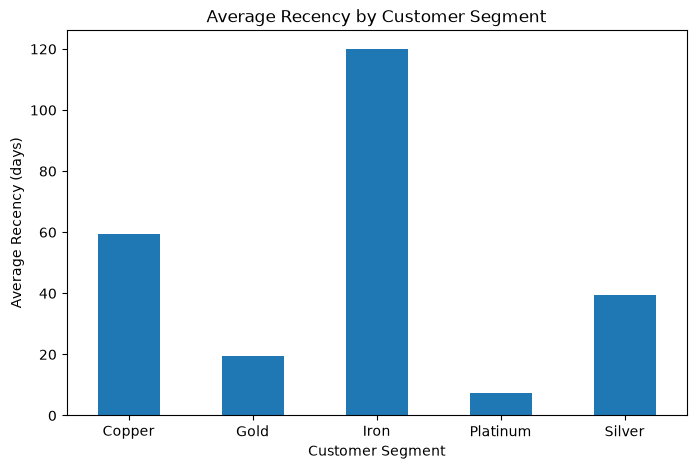

In [78]:
recency_by_segment.plot(kind="bar", figsize=(8,5))

plt.title("Average Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency (days)")
plt.xticks(rotation=0)

plt.show()

In [79]:
returns_by_segment = df.groupby("Segment_Label")["Returns"].mean().round(2)

print(returns_by_segment)

Segment_Label
Copper       9.45
Gold         4.47
Iron        11.85
Platinum     2.04
Silver       6.97
Name: Returns, dtype: float64


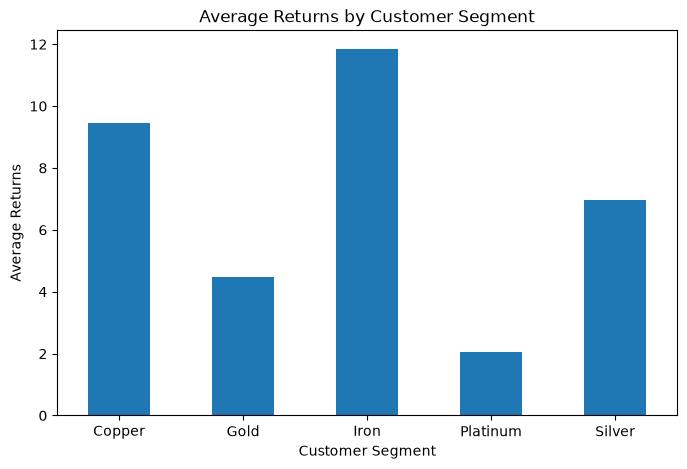

In [80]:
returns_by_segment.plot(kind="bar", figsize=(8,5))

plt.title("Average Returns by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Returns")
plt.xticks(rotation=0)

plt.show()

In [82]:
X = df.drop(columns=["Customer_ID", "Segment_Label"])
y = df["Segment_Label"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count',
       'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Campaign_Response',
       'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns'],
      dtype='str')

Target:
Segment_Label


In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 12)
X_test: (2000, 12)
y_train: (8000,)
y_test: (2000,)


In [87]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [88]:
import sklearn
print(sklearn.__version__)

1.9.0


In [89]:
y_pred_rf = model_rf.predict(X_test)

print(y_pred_rf[:20])

['Silver' 'Platinum' 'Copper' 'Platinum' 'Silver' 'Iron' 'Gold' 'Platinum'
 'Iron' 'Copper' 'Silver' 'Silver' 'Gold' 'Copper' 'Gold' 'Silver' 'Iron'
 'Silver' 'Copper' 'Gold']


In [90]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 1.0


In [91]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

      Copper       1.00      1.00      1.00       489
        Gold       1.00      1.00      1.00       404
        Iron       1.00      1.00      1.00       290
    Platinum       1.00      1.00      1.00       206
      Silver       1.00      1.00      1.00       611

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



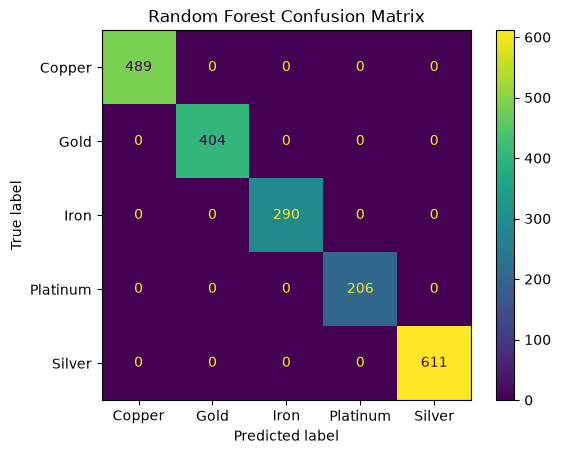

In [92]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_rf.classes_
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [93]:
print(cm)
print(model_rf.classes_)

[[489   0   0   0   0]
 [  0 404   0   0   0]
 [  0   0 290   0   0]
 [  0   0   0 206   0]
 [  0   0   0   0 611]]
['Copper' 'Gold' 'Iron' 'Platinum' 'Silver']


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [95]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [96]:
y_pred_lr = model_lr.predict(X_test_scaled)

print(y_pred_lr[:20])

['Silver' 'Platinum' 'Copper' 'Platinum' 'Silver' 'Iron' 'Gold' 'Platinum'
 'Iron' 'Copper' 'Silver' 'Silver' 'Gold' 'Copper' 'Gold' 'Silver' 'Iron'
 'Silver' 'Copper' 'Gold']


In [98]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9995


In [99]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [accuracy_rf, accuracy_lr]
})

print(comparison)

                 Model  Accuracy
0        Random Forest    1.0000
1  Logistic Regression    0.9995


In [100]:
import pickle

with open("customer_segment_model.pkl", "wb") as file:
    pickle.dump(model_rf, file)

print("Model saved successfully!")

Model saved successfully!


In [101]:
import os

print(os.path.exists("customer_segment_model.pkl"))

True


In [102]:
import os

print(os.getcwd())

C:\Users\user\Documents\e3
